# Exercise: Department Throughput Time

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## The Exercise

You will practice testing whether a **categorical X variable** has a significant effect on a **numerical Y variable**.

### Scenario

- **Y variable:** Throughput Time of a client request, measured in days (the CTQ)
- **X variable:** Department (A, B, or C)

### Question

**Are all departments equally fast?**

That is, is the throughput time equal across departments, or does one department have a longer throughput time than the others?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for department throughput analysis!')

Ready for department throughput analysis!


---

## Solution

### Determine Variable Types

First, check what variables you are dealing with:

| Question | Answer |
|----------|--------|
| What is my Y variable? | Throughput Time |
| What type of variable is this? | **Numerical** |
| What is the X variable (influence factor)? | Department |
| What type of variable is this? | **Categorical** |

### Which Technique to Use?

The tree diagram points us towards **ANOVA** with the possibility of a Kruskal-Wallis test.

---

## ANOVA: Three Steps

### Step 1: Organize Your Data

We check whether the data is in the correct format:
- Y variable (Throughput Time) in one column
- X variable (Department) in another column

Let's check our data...

In [2]:
# Load the department data
def load_departments():
    df = pd.read_excel(xlsx, sheet_name='Departments', skiprows=6, usecols=[0,1])
    df.columns = ['Department', 'Throughput_Time']
    return df.dropna()

departments = load_departments()

print('DATA FORMAT CHECK')
print('=' * 50)
print()
print('First 10 rows:')
print(departments.head(10))
print()
print('We have Department in one column and Throughput Time in the other.')
print('This is the format as it should be!')

DATA FORMAT CHECK

First 10 rows:
  Department  Throughput_Time
0          A             4.21
1          A             0.19
2          C             9.88
3          A             5.11
4          C            15.99
5          B             8.03
6          C            23.18
7          B            15.30
8          B            10.59
9          B            19.65

We have Department in one column and Throughput Time in the other.
This is the format as it should be!


---

### Step 2: Perform the ANOVA Analysis

In Minitab: **Stat > ANOVA > One-Way**
- Response: Throughput Time
- Factor: Department
- Options: Uncheck "Assume equal variances"
- Graphs: Individual value plot, Four-in-one residual plot

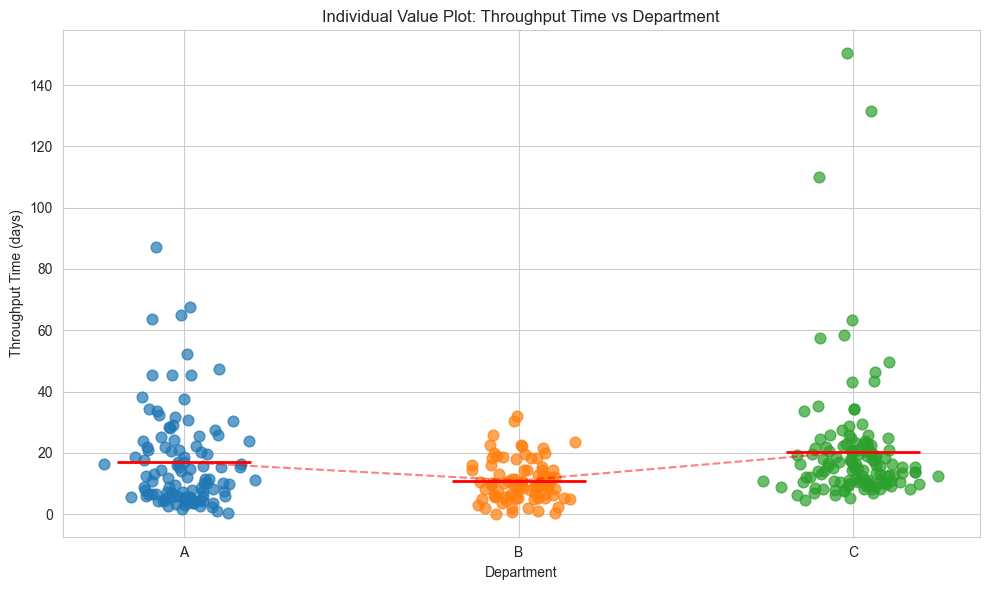

OBSERVATION:
  The lines in the individual value plot are NOT horizontal.
  This means we have found differences in the averages for each department.


In [3]:
# Individual Value Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Get data for each department
dept_A = departments[departments['Department'] == 'A']['Throughput_Time'].values
dept_B = departments[departments['Department'] == 'B']['Throughput_Time'].values
dept_C = departments[departments['Department'] == 'C']['Throughput_Time'].values

# Plot individual values
for i, (dept_data, dept_name) in enumerate([(dept_A, 'A'), (dept_B, 'B'), (dept_C, 'C')]):
    x = np.random.normal(i, 0.08, size=len(dept_data))
    ax.scatter(x, dept_data, alpha=0.7, s=60)
    # Add mean line
    mean = dept_data.mean()
    ax.hlines(mean, i-0.2, i+0.2, colors='red', linewidths=2)

# Connect means with line
means = [dept_A.mean(), dept_B.mean(), dept_C.mean()]
ax.plot([0, 1, 2], means, 'r--', alpha=0.5)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['A', 'B', 'C'])
ax.set_xlabel('Department')
ax.set_ylabel('Throughput Time (days)')
ax.set_title('Individual Value Plot: Throughput Time vs Department')

plt.tight_layout()
plt.show()

print('OBSERVATION:')
print('  The lines in the individual value plot are NOT horizontal.')
print('  This means we have found differences in the averages for each department.')

In [4]:
# ANOVA output
from scipy.stats import f_oneway

print('ANOVA OUTPUT')
print('=' * 60)
print()
print('Mean Throughput Time per Department:')
print('-' * 40)
for dept in ['A', 'B', 'C']:
    data = departments[departments['Department'] == dept]['Throughput_Time']
    print(f'  Department {dept}: Mean = {data.mean():.2f} days')
print()

# Perform ANOVA
f_stat, p_value = f_oneway(dept_A, dept_B, dept_C)

print('ANOVA Test:')
print('-' * 40)
print(f'  F-statistic: {f_stat:.3f}')
print(f'  P-value: {p_value:.4f}')
print()
print(f'P-value = {p_value:.4f}, which is lower than our 5% threshold.')
print()
print('We have found statistical evidence that there is a difference')
print('in throughput times across the departments.')
print()
print('However, we still need to check the residuals before we know')
print('if this conclusion is valid. This is Step 3.')

ANOVA OUTPUT

Mean Throughput Time per Department:
----------------------------------------
  Department A: Mean = 16.90 days
  Department B: Mean = 10.93 days
  Department C: Mean = 20.36 days

ANOVA Test:
----------------------------------------
  F-statistic: 9.224
  P-value: 0.0001

P-value = 0.0001, which is lower than our 5% threshold.

We have found statistical evidence that there is a difference
in throughput times across the departments.

However, we still need to check the residuals before we know
if this conclusion is valid. This is Step 3.


---

### Step 3: Check the Residuals

We already asked Minitab for the four-in-one plot. Let's check if the ANOVA assumptions are satisfied.

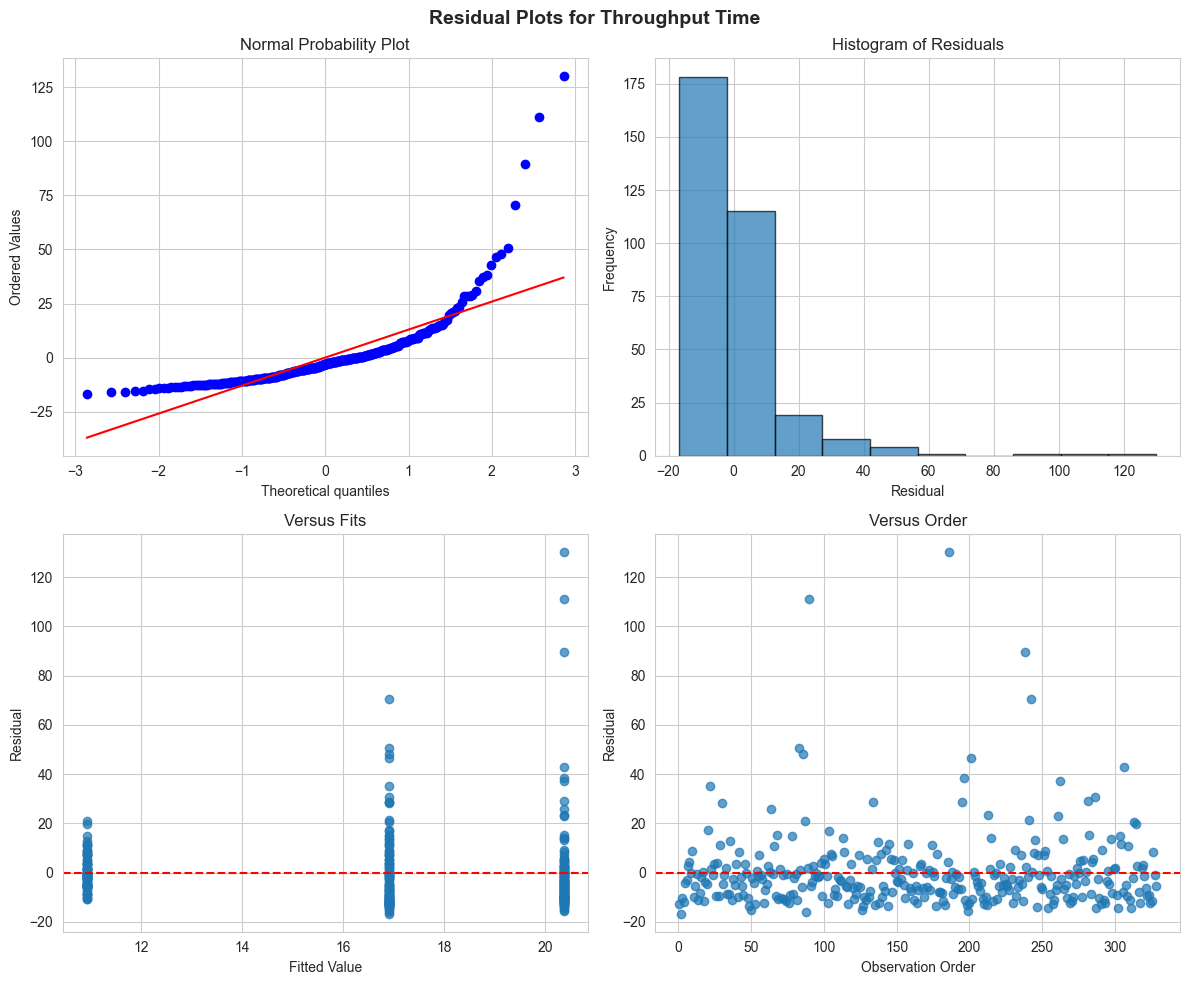

RESIDUAL ANALYSIS

In the normal probability plot, we clearly see that the
residuals are NOT normally distributed.

The time graph also shows some outliers.

Hence, we have to perform a Kruskal-Wallis analysis.


In [5]:
# Calculate residuals
group_means = departments.groupby('Department')['Throughput_Time'].transform('mean')
departments['Residual'] = departments['Throughput_Time'] - group_means
departments['Fitted'] = group_means
departments['Order'] = range(1, len(departments) + 1)

# Four-in-one residual plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

residuals = departments['Residual'].values

# 1. Normal probability plot
stats.probplot(residuals, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram
axes[0, 1].hist(residuals, bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Versus Fits
axes[1, 0].scatter(departments['Fitted'], residuals, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Versus Order
axes[1, 1].scatter(departments['Order'], residuals, alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for Throughput Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('RESIDUAL ANALYSIS')
print('=' * 60)
print()
print('In the normal probability plot, we clearly see that the')
print('residuals are NOT normally distributed.')
print()
print('The time graph also shows some outliers.')
print()
print('Hence, we have to perform a Kruskal-Wallis analysis.')

---

## Kruskal-Wallis Analysis

Since the residuals are not normally distributed, we perform the Kruskal-Wallis test.

In Minitab: **Stat > Nonparametrics > Kruskal-Wallis**
- Response: Throughput Time
- Factor: Department

In [6]:
# Kruskal-Wallis analysis
stat_kw, p_value_kw = stats.kruskal(dept_A, dept_B, dept_C)

print('KRUSKAL-WALLIS ANALYSIS')
print('=' * 60)
print()
print('Median Throughput Time per Department:')
print('-' * 40)
for dept in ['A', 'B', 'C']:
    data = departments[departments['Department'] == dept]['Throughput_Time']
    print(f'  Department {dept}: Median = {data.median():.2f} days')
print()
print('Test Results:')
print('-' * 40)
print(f'  H-statistic: {stat_kw:.3f}')
print(f'  P-value: {p_value_kw:.4f}')

KRUSKAL-WALLIS ANALYSIS

Median Throughput Time per Department:
----------------------------------------
  Department A: Median = 11.52 days
  Department B: Median = 9.89 days
  Department C: Median = 15.47 days

Test Results:
----------------------------------------
  H-statistic: 30.221
  P-value: 0.0000


In [7]:
# Interpret the result
print('INTERPRETATION')
print('=' * 60)
print()
print('The Kruskal-Wallis analysis CONFIRMS the conclusion of the ANOVA.')
print()
print(f'P-value = {p_value_kw:.4f}, which is below 5%.')
print()
print('Therefore, we find statistical evidence for a difference in the')
print('throughput times across the departments.')
print()
print('Department B has the smallest throughput time (fastest).')

INTERPRETATION

The Kruskal-Wallis analysis CONFIRMS the conclusion of the ANOVA.

P-value = 0.0000, which is below 5%.

Therefore, we find statistical evidence for a difference in the
throughput times across the departments.

Department B has the smallest throughput time (fastest).


---

## Important Note: Effect Size

A practitioner can now investigate what Department B does differently and try to learn from its best practices.

**But remember:** The variation within each department is very large, especially compared to the difference in the medians or means.

Therefore, **Department is only a small influence factor** on throughput time.

In [8]:
# Visualize the variation vs the difference in means
print('VARIATION VS DIFFERENCE IN MEANS')
print('=' * 60)
print()
print('Within-department variation (Std Dev):')
for dept in ['A', 'B', 'C']:
    data = departments[departments['Department'] == dept]['Throughput_Time']
    print(f'  Department {dept}: Std Dev = {data.std():.2f} days')
print()
print('Difference between means:')
print(f'  Highest (C) - Lowest (B) = {dept_C.mean() - dept_B.mean():.2f} days')
print()
print('The within-department variation is LARGE compared to the')
print('difference between department means.')

VARIATION VS DIFFERENCE IN MEANS

Within-department variation (Std Dev):
  Department A: Std Dev = 15.80 days
  Department B: Std Dev = 6.61 days
  Department C: Std Dev = 20.24 days

Difference between means:
  Highest (C) - Lowest (B) = 9.43 days

The within-department variation is LARGE compared to the
difference between department means.


---

## Summary

1. **We performed an ANOVA** on throughput time vs department

2. **During the residual check**, we found that they were NOT normally distributed
   - This is shown in the four-in-one plot

3. **We performed a Kruskal-Wallis analysis** to verify our ANOVA results
   - The Kruskal-Wallis showed a small p-value
   - We can conclude there is statistical evidence of a difference in average throughput times across departments

4. **Department B scored lowest** on throughput time and was therefore the fastest department

5. **Practical application:** This knowledge can now be used to search for best practices at Department B and implement these for Departments A and C